In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/fashionmnist


In [2]:
train_path = path+'/fashion-mnist_train.csv'
test_path = path+'/fashion-mnist_test.csv'

import pandas as pd

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

In [3]:
train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
train.shape, test.shape

((60000, 785), (10000, 785))

In [5]:
labs = {0 : 'T-shirt/top', 1 : 'Trouser', 2 : 'Pullover', 3 : 'Dress',
4 : 'Coat', 5 : 'Sandal', 6 : 'Shirt', 7 : 'Sneaker',
8 : 'Bag', 9 : 'Ankle boot'}

def labs_fun(index):
    return labs[index]

label_names = list(map(labs_fun, train['label']))

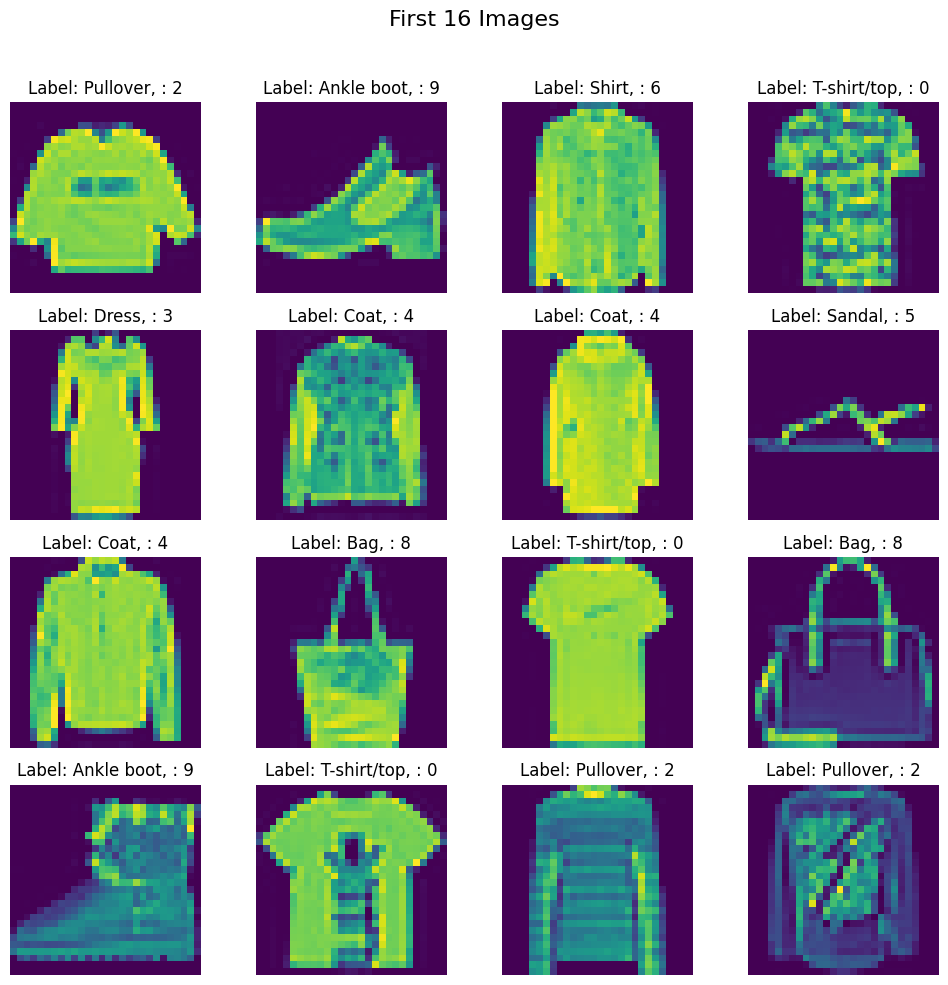

In [6]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

for i, ax in enumerate(axes.flat):
    img = train.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {label_names[i]}, : {train.iloc[i, 0]}");  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

In [7]:
import pandas as pd
import numpy as np
import umap
import plotly.express as px

# 1. 이미지 데이터 정규화 및 준비
x_train = train.drop(columns=['label']).values / 255.0
x_test = test.drop(columns=['label']).values / 255.0

n_samples = 3000
x_train_sample = x_train[:n_samples]
x_test_sample = x_test[:n_samples]

# 2. 도메인 라벨 설정
X = np.concatenate([x_train_sample, x_test_sample], axis=0)
y_domain = np.array(['train'] * n_samples + ['test'] * n_samples)

# 3. UMAP 3차원 임베딩
reducer = umap.UMAP(n_components=3, random_state=42)
embedding = reducer.fit_transform(X)

# 4. Plotly로 시각화
fig = px.scatter_3d(
    x=embedding[:, 0],
    y=embedding[:, 1],
    z=embedding[:, 2],
    color=y_domain,
    labels={'color': 'Domain'},
    title="Interactive 3D UMAP of Fashion MNIST"
)

fig.update_traces(marker=dict(size=0.5, opacity=0.6))
fig.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 도메인 라벨 부여
X = np.concatenate([x_train, x_test])
y = np.array([0] * len(x_train) + [1] * len(x_test))

# 분류기 학습
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)
clf = LogisticRegression(max_iter=1000000)
clf.fit(X_train, y_train)

# 정확도 측정
y_pred = clf.predict(X_val)
acc = accuracy_score(y_val, y_pred)
print("C2ST accuracy:", acc)

C2ST accuracy: 0.8579523809523809
